In [1]:
# Pottery Decoration Classification using DINOv2
# Binary classification: impressed vs incised pottery sherds

import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import time
import glob
import os
from pathlib import Path

# Import transformers for DINOv2
try:
    from transformers import AutoModel, AutoImageProcessor
    TRANSFORMERS_AVAILABLE = True
    print("✓ Hugging Face transformers available")
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("⚠ Hugging Face transformers not available")
    print("Install with: pip install transformers")
    raise ImportError("transformers library is required. Install with: pip install transformers")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


✓ Hugging Face transformers available
Libraries imported successfully!
PyTorch version: 2.8.0+cu126
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090


Loading pottery images...
Found 687 impressed images
Found 1391 incised images

Dataset loaded successfully!
Total images: 2078
Impressed: 687
Incised: 1391


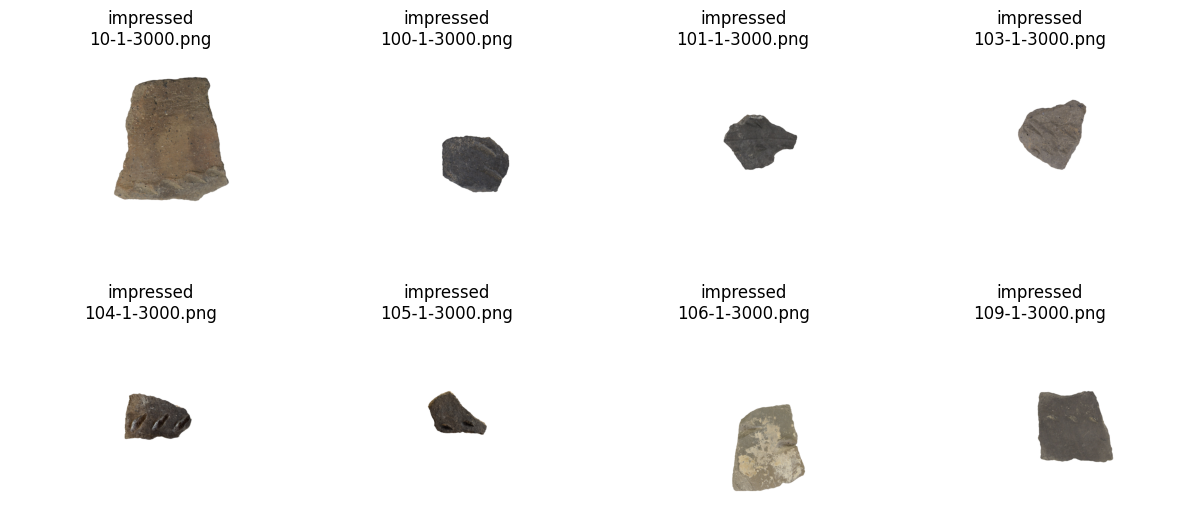

In [2]:
# 1. Dataset Loading
# Load transparent pottery images and convert RGBA to RGB

def load_pottery_images():
    """Load transparent pottery images and convert RGBA to RGB with white background"""
    images = []
    labels = []
    filenames = []
    
    # Paths to transparent images
    # go one level up from the current directory
    impressed_dir = "data/decoration/impressed_transparent"
    incised_dir = "data/decoration/incised_transparent"
    
    # Load impressed images
    impressed_files = glob.glob(os.path.join(impressed_dir, "*.png"))
    print(f"Found {len(impressed_files)} impressed images")
    
    for file_path in sorted(impressed_files):
        try:
            img = Image.open(file_path)
            if img.mode == 'RGBA':
                # Create white background
                background = Image.new('RGB', img.size, (255, 255, 255))
                background.paste(img, mask=img.split()[-1])  # Use alpha channel as mask
                img = background
            elif img.mode != 'RGB':
                img = img.convert('RGB')
            images.append(img)
            labels.append('impressed')
            filenames.append(os.path.basename(file_path))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    # Load incised images
    incised_files = glob.glob(os.path.join(incised_dir, "*.png"))
    print(f"Found {len(incised_files)} incised images")
    
    for file_path in sorted(incised_files):
        try:
            img = Image.open(file_path)
            if img.mode == 'RGBA':
                # Create white background
                background = Image.new('RGB', img.size, (255, 255, 255))
                background.paste(img, mask=img.split()[-1])  # Use alpha channel as mask
                img = background
            elif img.mode != 'RGB':
                img = img.convert('RGB')
            images.append(img)
            labels.append('incised')
            filenames.append(os.path.basename(file_path))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    return images, labels, filenames

# Load the dataset
print("Loading pottery images...")
images, labels, filenames = load_pottery_images()

print(f"\nDataset loaded successfully!")
print(f"Total images: {len(images)}")
print(f"Impressed: {labels.count('impressed')}")
print(f"Incised: {labels.count('incised')}")

# Display sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(images[i])
    axes[row, col].set_title(f"{labels[i]}\n{filenames[i]}")
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()


In [3]:
# 2. Model Setup & Loading
# Load DINOv2 models via Hugging Face transformers

def load_models():
    """Load DINOv2 models from Hugging Face"""
    models = {}
    
    print("Loading DINOv2 models from Hugging Face transformers...")
    
    try:
        # DINOv2 small (ViT-S/14)
        models['dinov2_vits14'] = AutoModel.from_pretrained('facebook/dinov2-small')
        print("✓ DINOv2 ViT-S/14 loaded")
        
        # DINOv2 large (ViT-L/14)
        models['dinov2_vitl14'] = AutoModel.from_pretrained('facebook/dinov2-large')
        print("✓ DINOv2 ViT-L/14 loaded")
        
    except Exception as e:
        print(f"Error loading DINOv2 models: {e}")
        print("Note: DINOv2 models may require license acceptance on Hugging Face")
        print("Visit: https://huggingface.co/facebook/dinov2-small")
        raise
    
    # Set models to eval mode and move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nUsing device: {device}")
    
    for name, model in models.items():
        model.eval()
        model.to(device)
        print(f"✓ {name} moved to {device}")
    
    return models, device

# Load all models
models, device = load_models()
print(f"\nLoaded {len(models)} models successfully!")


Loading DINOv2 models from Hugging Face transformers...
✓ DINOv2 ViT-S/14 loaded
✓ DINOv2 ViT-L/14 loaded

Using device: cuda
✓ dinov2_vits14 moved to cuda
✓ dinov2_vitl14 moved to cuda

Loaded 2 models successfully!


In [4]:
# 3. Model Comparison with 200+2000 Images per Class
# Test all models with balanced samples and train simple classifiers

def get_embedding(model, image, device, model_name):
    """Generate embedding for a single image"""
    # Standard DINO preprocessing
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Preprocess image
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Generate embedding
    with torch.no_grad():
        outputs = model(image_tensor)
        # Use the last hidden state (pooler_output or last_hidden_state)
        if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
            embedding = outputs.pooler_output
        else:
            # Use mean of last hidden state
            embedding = outputs.last_hidden_state.mean(dim=1)
    
    return embedding.cpu().numpy().flatten()

def extract_embeddings_for_model(model, model_name, images, labels, device, max_samples_per_class=200):
    """Extract embeddings for a balanced subset of images"""
    # Get indices for each class
    impressed_indices = [i for i, label in enumerate(labels) if label == 'impressed']
    incised_indices = [i for i, label in enumerate(labels) if label == 'incised']
    
    # Sample balanced subset
    np.random.seed(42)  # For reproducibility
    impressed_sample = np.random.choice(impressed_indices, 
                                       min(max_samples_per_class, len(impressed_indices)), 
                                       replace=False)
    incised_sample = np.random.choice(incised_indices, 
                                    min(max_samples_per_class, len(incised_indices)), 
                                    replace=False)
    
    # Combine samples
    sample_indices = np.concatenate([impressed_sample, incised_sample])
    sample_images = [images[i] for i in sample_indices]
    sample_labels = [labels[i] for i in sample_indices]
    
    print(f"Processing {len(sample_images)} images for {model_name}...")
    print(f"  Impressed: {len(impressed_sample)}, Incised: {len(incised_sample)}")
    
    # Extract embeddings
    embeddings = []
    times = []
    
    for i, image in enumerate(sample_images):
        start_time = time.time()
        embedding = get_embedding(model, image, device, model_name)
        end_time = time.time()
        
        embeddings.append(embedding)
        times.append(end_time - start_time)
        
        if (i + 1) % 20 == 0:
            print(f"  Processed {i + 1}/{len(sample_images)} images")
    
    avg_time = np.mean(times)
    embedding_dim = embeddings[0].shape[0]
    
    print(f"  Average time per image: {avg_time:.4f}s")
    print(f"  Embedding dimension: {embedding_dim}")
    
    return np.array(embeddings), sample_labels, avg_time

def train_simple_classifiers(embeddings, labels, model_name):
    """Train logistic regression and SVM on embeddings"""
    from sklearn.preprocessing import LabelEncoder
    
    # Encode labels
    label_encoder = LabelEncoder()
    y_numeric = label_encoder.fit_transform(labels)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric
    )
    
    # Train classifiers
    classifiers = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Linear SVM': SVC(kernel='linear', random_state=42)
    }
    
    results = {}
    
    for name, clf in classifiers.items():
        # Train
        start_time = time.time()
        clf.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Predict
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        results[name] = {
            'accuracy': accuracy,
            'train_time': train_time,
            'classifier': clf
        }
        
        print(f"  {name}: {accuracy:.4f} accuracy, {train_time:.2f}s training")
    
    return results, label_encoder

# Compare all models with balanced samples
print("Comparing all models with 200+200 samples per class...")
print("=" * 70)

model_comparison_results = {}

for model_name, model in models.items():
    print(f"\n{'='*20} {model_name.upper()} {'='*20}")
    
    # Extract embeddings
    embeddings, sample_labels, avg_time = extract_embeddings_for_model(
        model, model_name, images, labels, device, max_samples_per_class=200
    )
    
    # Train simple classifiers
    classifier_results, label_encoder = train_simple_classifiers(
        embeddings, sample_labels, model_name
    )
    
    # Store results
    model_comparison_results[model_name] = {
        'embeddings': embeddings,
        'labels': sample_labels,
        'avg_time': avg_time,
        'classifier_results': classifier_results,
        'label_encoder': label_encoder
    }

print(f"\n{'='*70}")
print("MODEL COMPARISON SUMMARY")
print("=" * 70)


Comparing all models with 200+200 samples per class...

==================== DINOV2_VITS14 ====================
Processing 400 images for dinov2_vits14...
  Impressed: 200, Incised: 200
  Processed 20/400 images
  Processed 40/400 images
  Processed 60/400 images
  Processed 80/400 images
  Processed 100/400 images
  Processed 120/400 images
  Processed 140/400 images
  Processed 160/400 images
  Processed 180/400 images
  Processed 200/400 images
  Processed 220/400 images
  Processed 240/400 images
  Processed 260/400 images
  Processed 280/400 images
  Processed 300/400 images
  Processed 320/400 images
  Processed 340/400 images
  Processed 360/400 images
  Processed 380/400 images
  Processed 400/400 images
  Average time per image: 0.0231s
  Embedding dimension: 384
  Logistic Regression: 0.7750 accuracy, 0.03s training
  Linear SVM: 0.7625 accuracy, 0.01s training

==================== DINOV2_VITL14 ====================
Processing 400 images for dinov2_vitl14...
  Impressed: 200

C:\Users\Shahab\AppData\Local\Temp\ipykernel_31752\3648006236.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([name.replace('_', '\n') for name in model_names], rotation=45)
C:\Users\Shahab\AppData\Local\Temp\ipykernel_31752\3648006236.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels([name.replace('_', '\n') for name in model_names], rotation=45)


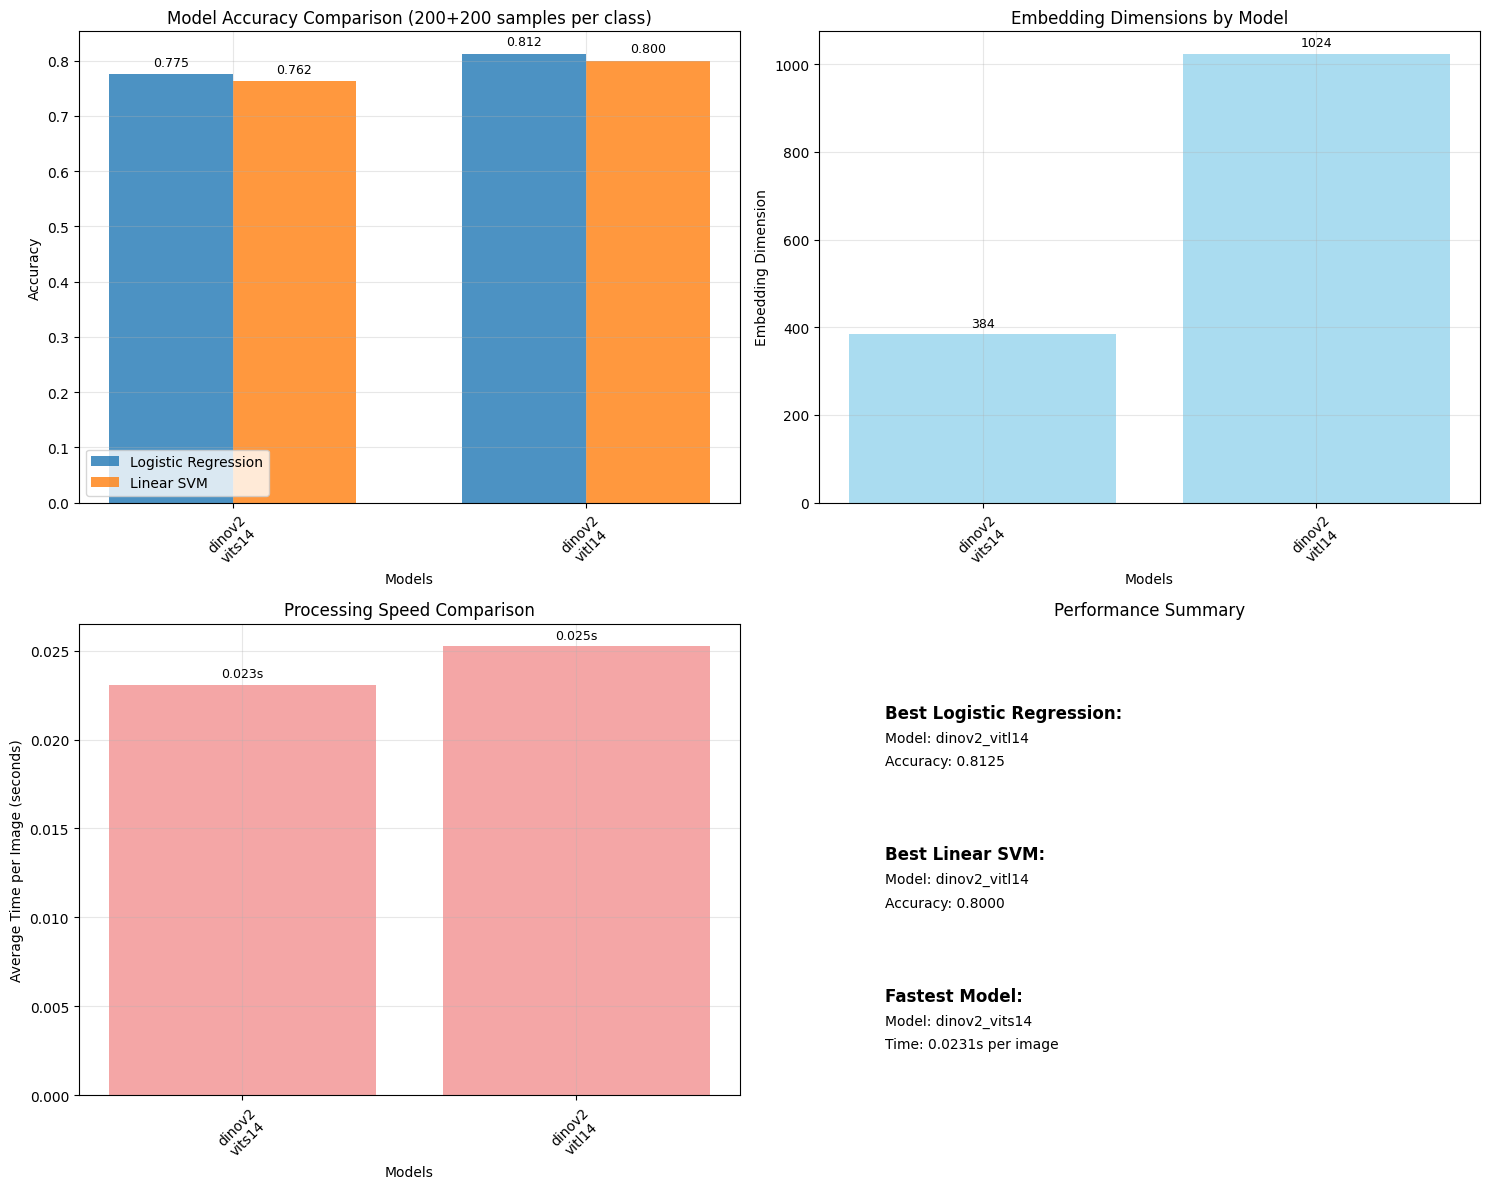


DETAILED COMPARISON RESULTS
Model                LogReg Acc   SVM Acc      Dim      Time/img    
--------------------------------------------------------------------------------
dinov2_vits14        0.7750       0.7625       384      0.0231      
dinov2_vitl14        0.8125       0.8000       1024     0.0252      

Best overall performance:
  Logistic Regression: dinov2_vitl14 (0.8125)
  Linear SVM: dinov2_vitl14 (0.8000)
  Fastest processing: dinov2_vits14 (0.0231s per image)


In [5]:
# 4. Accuracy Comparison Visualization
# Create graphs showing model performance comparison

# Prepare data for visualization
model_names = []
logreg_accuracies = []
svm_accuracies = []
embedding_dims = []
processing_times = []

for model_name, results in model_comparison_results.items():
    model_names.append(model_name)
    logreg_accuracies.append(results['classifier_results']['Logistic Regression']['accuracy'])
    svm_accuracies.append(results['classifier_results']['Linear SVM']['accuracy'])
    embedding_dims.append(results['embeddings'].shape[1])
    processing_times.append(results['avg_time'])

# Create comparison plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy Comparison
x_pos = np.arange(len(model_names))
width = 0.35

ax1.bar(x_pos - width/2, logreg_accuracies, width, label='Logistic Regression', alpha=0.8)
ax1.bar(x_pos + width/2, svm_accuracies, width, label='Linear SVM', alpha=0.8)
ax1.set_xlabel('Models')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison (200+200 samples per class)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([name.replace('_', '\n') for name in model_names], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for i, (lr_acc, svm_acc) in enumerate(zip(logreg_accuracies, svm_accuracies)):
    ax1.text(i - width/2, lr_acc + 0.01, f'{lr_acc:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(i + width/2, svm_acc + 0.01, f'{svm_acc:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Embedding Dimensions
ax2.bar(model_names, embedding_dims, alpha=0.7, color='skyblue')
ax2.set_xlabel('Models')
ax2.set_ylabel('Embedding Dimension')
ax2.set_title('Embedding Dimensions by Model')
ax2.set_xticklabels([name.replace('_', '\n') for name in model_names], rotation=45)
ax2.grid(True, alpha=0.3)

# Add value labels
for i, dim in enumerate(embedding_dims):
    ax2.text(i, dim + max(embedding_dims)*0.01, f'{dim}', ha='center', va='bottom', fontsize=9)

# 3. Processing Time Comparison
ax3.bar(model_names, processing_times, alpha=0.7, color='lightcoral')
ax3.set_xlabel('Models')
ax3.set_ylabel('Average Time per Image (seconds)')
ax3.set_title('Processing Speed Comparison')
ax3.set_xticklabels([name.replace('_', '\n') for name in model_names], rotation=45)
ax3.grid(True, alpha=0.3)

# Add value labels
for i, time_val in enumerate(processing_times):
    ax3.text(i, time_val + max(processing_times)*0.01, f'{time_val:.3f}s', ha='center', va='bottom', fontsize=9)

# 4. Best Model Performance Summary
best_lr_idx = np.argmax(logreg_accuracies)
best_svm_idx = np.argmax(svm_accuracies)

ax4.text(0.1, 0.8, f'Best Logistic Regression:', fontsize=12, fontweight='bold', transform=ax4.transAxes)
ax4.text(0.1, 0.75, f'Model: {model_names[best_lr_idx]}', fontsize=10, transform=ax4.transAxes)
ax4.text(0.1, 0.7, f'Accuracy: {logreg_accuracies[best_lr_idx]:.4f}', fontsize=10, transform=ax4.transAxes)

ax4.text(0.1, 0.5, f'Best Linear SVM:', fontsize=12, fontweight='bold', transform=ax4.transAxes)
ax4.text(0.1, 0.45, f'Model: {model_names[best_svm_idx]}', fontsize=10, transform=ax4.transAxes)
ax4.text(0.1, 0.4, f'Accuracy: {svm_accuracies[best_svm_idx]:.4f}', fontsize=10, transform=ax4.transAxes)

ax4.text(0.1, 0.2, f'Fastest Model:', fontsize=12, fontweight='bold', transform=ax4.transAxes)
fastest_idx = np.argmin(processing_times)
ax4.text(0.1, 0.15, f'Model: {model_names[fastest_idx]}', fontsize=10, transform=ax4.transAxes)
ax4.text(0.1, 0.1, f'Time: {processing_times[fastest_idx]:.4f}s per image', fontsize=10, transform=ax4.transAxes)

ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')
ax4.set_title('Performance Summary')

plt.tight_layout()
plt.show()

# Print detailed results table
print("\n" + "=" * 80)
print("DETAILED COMPARISON RESULTS")
print("=" * 80)
print(f"{'Model':<20} {'LogReg Acc':<12} {'SVM Acc':<12} {'Dim':<8} {'Time/img':<12}")
print("-" * 80)

for i, model_name in enumerate(model_names):
    print(f"{model_name:<20} {logreg_accuracies[i]:<12.4f} {svm_accuracies[i]:<12.4f} {embedding_dims[i]:<8} {processing_times[i]:<12.4f}")

print(f"\nBest overall performance:")
print(f"  Logistic Regression: {model_names[best_lr_idx]} ({logreg_accuracies[best_lr_idx]:.4f})")
print(f"  Linear SVM: {model_names[best_svm_idx]} ({svm_accuracies[best_svm_idx]:.4f})")
print(f"  Fastest processing: {model_names[fastest_idx]} ({processing_times[fastest_idx]:.4f}s per image)")


In [6]:
# 5. Feature Extraction for Full Dataset
# Extract embeddings for all images using selected model

# Model selection - change this to use different models
# Available models: dinov2_vits14, dinov2_vitl14
selected_model_name = "dinov2_vitl14"  # Change this to select different model

print(f"Selected model: {selected_model_name}")
print(f"Available models: {list(models.keys())}")

# Show comparison results to help with selection
print(f"\nModel comparison results from previous evaluation:")
print(f"{'Model':<20} {'LogReg Acc':<12} {'SVM Acc':<12} {'Time/img':<12}")
print("-" * 60)
for i, model_name in enumerate(model_names):
    print(f"{model_name:<20} {logreg_accuracies[i]:<12.4f} {svm_accuracies[i]:<12.4f} {processing_times[i]:<12.4f}")

if selected_model_name not in models:
    print(f"\nError: {selected_model_name} not found in loaded models!")
    print("Available models:", list(models.keys()))
    # Fallback to best performing model
    best_lr_idx = np.argmax(logreg_accuracies)
    selected_model_name = model_names[best_lr_idx]
    selected_model = models[selected_model_name]
    print(f"Falling back to best model: {selected_model_name}")
else:
    selected_model = models[selected_model_name]
    print(f"✓ Using {selected_model_name} for full dataset feature extraction")

def extract_features_for_dataset(model, images, device, batch_size=32):
    """Extract features for entire dataset"""
    print(f"Extracting features for {len(images)} images...")
    
    # Standard DINO preprocessing
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    features = []
    
    # Process in batches
    for i in range(0, len(images), batch_size):
        batch_images = images[i:i+batch_size]
        batch_tensors = []
        
        # Preprocess batch
        for img in batch_images:
            tensor = transform(img)
            batch_tensors.append(tensor)
        
        # Stack into batch tensor
        batch_tensor = torch.stack(batch_tensors).to(device)
        
        # Extract features
        with torch.no_grad():
            outputs = model(batch_tensor)
            if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                batch_features = outputs.pooler_output
            else:
                # Use mean of last hidden state
                batch_features = outputs.last_hidden_state.mean(dim=1)
            features.append(batch_features.cpu().numpy())
        
        if (i // batch_size + 1) % 10 == 0:
            print(f"  Processed {i + len(batch_images)}/{len(images)} images")
    
    # Concatenate all features
    all_features = np.vstack(features)
    print(f"✓ Extracted features shape: {all_features.shape}")
    
    return all_features

# Extract features using selected model
if selected_model_name in models:
    features = extract_features_for_dataset(selected_model, images, device)
    print(f"Feature extraction completed!")
    print(f"Features shape: {features.shape}")
    print(f"Feature dimension: {features.shape[1]}")
else:
    print("Skipping feature extraction due to model not found")


Selected model: dinov2_vitl14
Available models: ['dinov2_vits14', 'dinov2_vitl14']

Model comparison results from previous evaluation:
Model                LogReg Acc   SVM Acc      Time/img    
------------------------------------------------------------
dinov2_vits14        0.7750       0.7625       0.0231      
dinov2_vitl14        0.8125       0.8000       0.0252      
✓ Using dinov2_vitl14 for full dataset feature extraction
Extracting features for 2078 images...
  Processed 320/2078 images
  Processed 640/2078 images
  Processed 960/2078 images
  Processed 1280/2078 images
  Processed 1600/2078 images
  Processed 1920/2078 images
✓ Extracted features shape: (2078, 1024)
Feature extraction completed!
Features shape: (2078, 1024)
Feature dimension: 1024


In [7]:
# 5b. Data Augmentation for Training
# Apply augmentation to increase training data diversity

def extract_features_with_augmentation(model, images, device, augmentation_factor=5):
    """Extract features with data augmentation for more robust training"""
    print(f"Extracting features with {augmentation_factor}x augmentation...")
    
    # Base preprocessing
    base_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Augmentation transforms for training
    augmentation_transforms = [
        transforms.Compose([
            transforms.Resize(256),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
        transforms.Compose([
            transforms.Resize(256),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(30),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
        transforms.Compose([
            transforms.Resize(256),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    ]
    
    features_list = []
    labels_list = []
    
    # Extract original features
    print("Extracting original features...")
    for i, img in enumerate(images):
        tensor = base_transform(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            outputs = model(tensor)
            if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                feature = outputs.pooler_output
            else:
                feature = outputs.last_hidden_state.mean(dim=1)
        
        features_list.append(feature.cpu().numpy())
        labels_list.append(labels[i])
        
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(images)} images")
    
    # Extract augmented features
    print(f"Extracting {augmentation_factor - 1} augmented versions per image...")
    for aug_idx in range(augmentation_factor - 1):
        transform = augmentation_transforms[aug_idx % len(augmentation_transforms)]
        print(f"  Augmentation round {aug_idx + 1}/{augmentation_factor - 1}")
        
        for i, img in enumerate(images):
            tensor = transform(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                outputs = model(tensor)
                if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                    feature = outputs.pooler_output
                else:
                    feature = outputs.last_hidden_state.mean(dim=1)
            
            features_list.append(feature.cpu().numpy())
            labels_list.append(labels[i])
            
            if (i + 1) % 50 == 0:
                print(f"    Processed {i + 1}/{len(images)} images")
    
    augmented_features = np.vstack(features_list)
    print(f"✓ Total features extracted: {augmented_features.shape}")
    print(f"  Original: {len(images)}")
    print(f"  Augmented total: {augmented_features.shape[0]}")
    
    return augmented_features, labels_list

# Extract features with augmentation (change augmentation_factor to control amount)
print("\n" + "=" * 70)
print("EXTRACTING FEATURES WITH DATA AUGMENTATION")
print("=" * 70)

features_augmented, labels_augmented = extract_features_with_augmentation(
    selected_model, images, device, augmentation_factor=3
)

print(f"\n✓ Feature extraction with augmentation completed!")
print(f"Features shape: {features_augmented.shape}")
print(f"Labels count: {len(labels_augmented)}")


EXTRACTING FEATURES WITH DATA AUGMENTATION
Extracting features with 3x augmentation...
Extracting original features...
  Processed 50/2078 images
  Processed 100/2078 images
  Processed 150/2078 images
  Processed 200/2078 images
  Processed 250/2078 images
  Processed 300/2078 images
  Processed 350/2078 images
  Processed 400/2078 images
  Processed 450/2078 images
  Processed 500/2078 images
  Processed 550/2078 images
  Processed 600/2078 images
  Processed 650/2078 images
  Processed 700/2078 images
  Processed 750/2078 images
  Processed 800/2078 images
  Processed 850/2078 images
  Processed 900/2078 images
  Processed 950/2078 images
  Processed 1000/2078 images
  Processed 1050/2078 images
  Processed 1100/2078 images
  Processed 1150/2078 images
  Processed 1200/2078 images
  Processed 1250/2078 images
  Processed 1300/2078 images
  Processed 1350/2078 images
  Processed 1400/2078 images
  Processed 1450/2078 images
  Processed 1500/2078 images
  Processed 1550/2078 images
 

In [8]:
# 5c. Fine-tuning Option - Train a classifier head on top of DINOv2
# This adds a trainable classification layer on top of frozen DINOv2 features

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class PotteryDataset(Dataset):
    """Custom dataset for pottery images"""
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform
        self.label_map = {'impressed': 0, 'incised': 1}
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.label_map[self.labels[idx]]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

class DINOClassifier(nn.Module):
    """DINOv2 feature extractor + trainable classification head"""
    def __init__(self, dino_model, feature_dim, num_classes=2):
        super(DINOClassifier, self).__init__()
        self.dino_model = dino_model
        
        # Freeze DINOv2 backbone
        for param in self.dino_model.parameters():
            param.requires_grad = False
        
        # Trainable classification head with dropout for regularization
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        # Extract DINOv2 features (frozen)
        with torch.no_grad():
            outputs = self.dino_model(x)
            if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                features = outputs.pooler_output
            else:
                features = outputs.last_hidden_state.mean(dim=1)
        
        # Pass through trainable classifier
        logits = self.classifier(features)
        return logits

def train_fine_tuned_model(model_name='dinov2_vits14', epochs=20, batch_size=16, lr=0.001):
    """Fine-tune a classification head on DINOv2 features"""
    print(f"\n{'='*70}")
    print(f"FINE-TUNING CLASSIFICATION HEAD ON {model_name.upper()}")
    print(f"{'='*70}")
    
    # Get model and feature dimension
    if model_name not in models:
        print(f"Error: {model_name} not available")
        return None
    
    base_model = models[model_name]
    
    # Determine feature dimension
    test_transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_img = test_transform(images[0]).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = base_model(test_img)
        if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
            test_feat = outputs.pooler_output
        else:
            test_feat = outputs.last_hidden_state.mean(dim=1)
    feature_dim = test_feat.shape[1]
    print(f"Feature dimension: {feature_dim}")
    
    # Create model
    model = DINOClassifier(base_model, feature_dim, num_classes=2).to(device)
    
    # Data transforms with augmentation
    train_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Split data
    from sklearn.model_selection import train_test_split
    train_imgs, test_imgs, train_lbls, test_lbls = train_test_split(
        images, labels, test_size=0.2, random_state=42, stratify=labels
    )
    
    # Create datasets and loaders
    train_dataset = PotteryDataset(train_imgs, train_lbls, train_transform)
    test_dataset = PotteryDataset(test_imgs, test_lbls, test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    print(f"\nTraining parameters:")
    print(f"  Epochs: {epochs}")
    print(f"  Batch size: {batch_size}")
    print(f"  Learning rate: {lr}")
    print(f"  Train samples: {len(train_dataset)}")
    print(f"  Test samples: {len(test_dataset)}")
    
    # Training loop
    best_accuracy = 0.0
    train_losses = []
    test_accuracies = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        model.dino_model.eval()  # Keep DINO frozen
        running_loss = 0.0
        
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        
        # Evaluation
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        accuracy = 100.0 * correct / total
        test_accuracies.append(accuracy)
        
        # Learning rate scheduling
        scheduler.step(accuracy)
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Test Accuracy: {accuracy:.2f}%")
        
        # Save best model
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model_state = model.state_dict()
            print(f"  ✓ New best accuracy: {best_accuracy:.2f}%")
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    print(f"\n{'='*70}")
    print(f"FINE-TUNING COMPLETED")
    print(f"Best Test Accuracy: {best_accuracy:.2f}%")
    print(f"{'='*70}")
    
    # Plot training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(train_losses)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Training Loss')
    ax1.set_title('Training Loss Over Time')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(test_accuracies)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Test Accuracy (%)')
    ax2.set_title('Test Accuracy Over Time')
    ax2.axhline(y=best_accuracy, color='r', linestyle='--', label=f'Best: {best_accuracy:.2f}%')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return model, best_accuracy

# Run fine-tuning (uncomment to execute)
# fine_tuned_model, best_acc = train_fine_tuned_model(
#     model_name='dinov2_vits14',
#     epochs=30,
#     batch_size=16,
#     lr=0.001
# )

In [9]:
# 6. Train/Test Split
# Create stratified 80/20 split maintaining class balance

from sklearn.preprocessing import LabelEncoder

# Convert string labels to numeric
label_encoder = LabelEncoder()
y_numeric = label_encoder.fit_transform(labels)

print("Dataset statistics:")
print(f"Total samples: {len(labels)}")
print(f"Impressed: {labels.count('impressed')} ({labels.count('impressed')/len(labels)*100:.1f}%)")
print(f"Incised: {labels.count('incised')} ({labels.count('incised')/len(labels)*100:.1f}%)")

# Create stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features, y_numeric, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_numeric
)

print(f"\nTrain/Test split:")
print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Check class distribution in splits
train_labels = label_encoder.inverse_transform(y_train)
test_labels = label_encoder.inverse_transform(y_test)

print(f"\nTrain set distribution:")
print(f"  Impressed: {train_labels.tolist().count('impressed')} ({train_labels.tolist().count('impressed')/len(train_labels)*100:.1f}%)")
print(f"  Incised: {train_labels.tolist().count('incised')} ({train_labels.tolist().count('incised')/len(train_labels)*100:.1f}%)")

print(f"\nTest set distribution:")
print(f"  Impressed: {test_labels.tolist().count('impressed')} ({test_labels.tolist().count('impressed')/len(test_labels)*100:.1f}%)")
print(f"  Incised: {test_labels.tolist().count('incised')} ({test_labels.tolist().count('incised')/len(test_labels)*100:.1f}%)")

print(f"\nFeature dimensions:")
print(f"  Train features: {X_train.shape}")
print(f"  Test features: {X_test.shape}")


Dataset statistics:
Total samples: 2078
Impressed: 687 (33.1%)
Incised: 1391 (66.9%)

Train/Test split:
Train samples: 1662
Test samples: 416

Train set distribution:
  Impressed: 549 (33.0%)
  Incised: 1113 (67.0%)

Test set distribution:
  Impressed: 138 (33.2%)
  Incised: 278 (66.8%)

Feature dimensions:
  Train features: (1662, 1024)
  Test features: (416, 1024)


In [10]:
# 7. Model Training
# Train multiple classifiers on extracted features

# Try to import XGBoost, but don't fail if not available
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not available, will skip XGBoost training")

def train_classifiers(X_train, y_train, X_test, y_test):
    """Train multiple classifiers and return results"""
    classifiers = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Linear SVM': SVC(kernel='linear', random_state=42),
        'RBF SVM': SVC(kernel='rbf', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
    }
    
    # Add XGBoost if available
    if XGBOOST_AVAILABLE:
        classifiers['XGBoost'] = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    
    results = {}
    
    print("Training classifiers...")
    print("=" * 50)
    
    for name, clf in classifiers.items():
        print(f"\nTraining {name}...")
        
        # Train classifier
        start_time = time.time()
        clf.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Make predictions
        y_pred = clf.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        
        results[name] = {
            'classifier': clf,
            'accuracy': accuracy,
            'predictions': y_pred,
            'train_time': train_time
        }
        
        print(f"  Training time: {train_time:.2f}s")
        print(f"  Accuracy: {accuracy:.4f}")
    
    return results

# Train all classifiers
classifier_results = train_classifiers(X_train, y_train, X_test, y_test)

print(f"\n✓ Trained {len(classifier_results)} classifiers successfully!")


✓ XGBoost available
Training classifiers...

Training Logistic Regression...
  Training time: 0.19s
  Accuracy: 0.8365

Training Linear SVM...
  Training time: 0.24s
  Accuracy: 0.8221

Training RBF SVM...
  Training time: 0.18s
  Accuracy: 0.8726

Training Random Forest...
  Training time: 2.56s
  Accuracy: 0.8197

Training XGBoost...
  Training time: 2.19s
  Accuracy: 0.8462

✓ Trained 5 classifiers successfully!



ENSEMBLE MODEL PREDICTIONS
Logistic Regression: 0.8365
Linear SVM: 0.8221
RBF SVM: 0.8726
Random Forest: 0.8197
XGBoost: 0.8462

ENSEMBLE RESULTS
Hard Voting Accuracy: 0.8630

Ensemble Classification Report:
              precision    recall  f1-score   support

   impressed       0.85      0.71      0.77       138
     incised       0.87      0.94      0.90       278

    accuracy                           0.86       416
   macro avg       0.86      0.82      0.84       416
weighted avg       0.86      0.86      0.86       416


Ensemble Confusion Matrix:
                 Predicted
                impressed  incised
Actual impressed       98       40
        incised       17      261

Model weights for weighted voting:
  Logistic Regression: 0.1993
  Linear SVM: 0.1959
  RBF SVM: 0.2079
  Random Forest: 0.1953
  XGBoost: 0.2016

Weighted Voting Accuracy: 0.8750


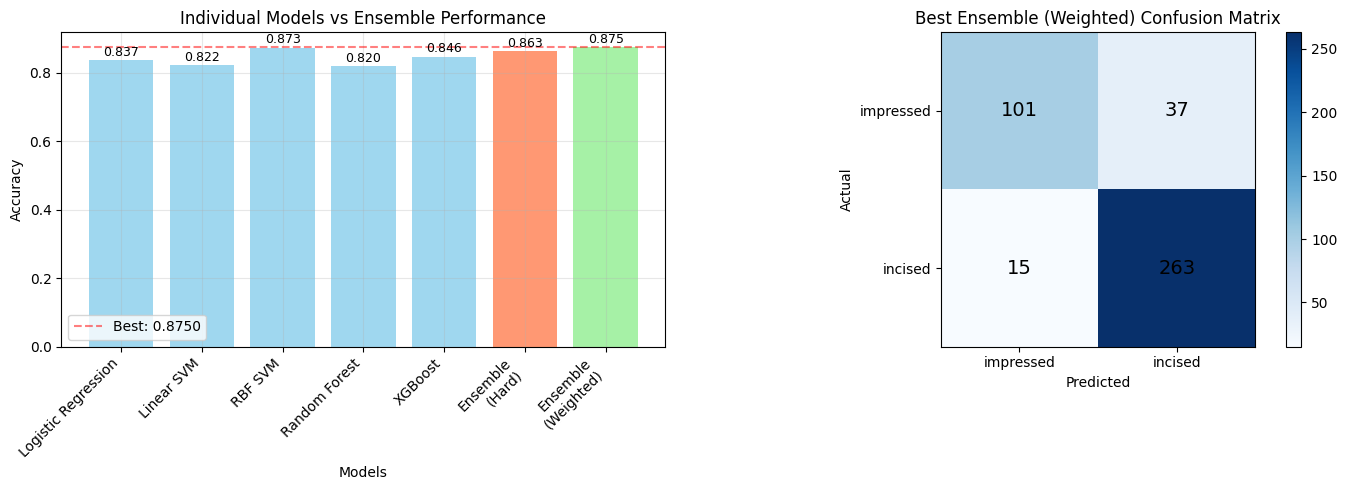

In [11]:
# 7b. Ensemble Methods
# Combine predictions from multiple models for improved accuracy

def create_ensemble_predictions(X_test, y_test, classifier_results):
    """Create ensemble predictions using voting"""
    print("\n" + "=" * 70)
    print("ENSEMBLE MODEL PREDICTIONS")
    print("=" * 70)
    
    # Collect all predictions
    all_predictions = []
    model_names = []
    
    for name, results in classifier_results.items():
        clf = results['classifier']
        y_pred = clf.predict(X_test)
        all_predictions.append(y_pred)
        model_names.append(name)
        print(f"{name}: {accuracy_score(y_test, y_pred):.4f}")
    
    # Convert to numpy array for easier manipulation
    predictions_array = np.array(all_predictions)
    
    # Hard voting ensemble
    from scipy import stats
    ensemble_predictions_hard = stats.mode(predictions_array, axis=0, keepdims=False)[0]
    ensemble_accuracy_hard = accuracy_score(y_test, ensemble_predictions_hard)
    
    print(f"\n{'='*70}")
    print(f"ENSEMBLE RESULTS")
    print(f"{'='*70}")
    print(f"Hard Voting Accuracy: {ensemble_accuracy_hard:.4f}")
    
    # Detailed report
    print("\nEnsemble Classification Report:")
    print(classification_report(y_test, ensemble_predictions_hard, 
                              target_names=label_encoder.classes_))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, ensemble_predictions_hard)
    print("\nEnsemble Confusion Matrix:")
    print(f"                 Predicted")
    print(f"                {label_encoder.classes_[0]:>8} {label_encoder.classes_[1]:>8}")
    print(f"Actual {label_encoder.classes_[0]:>8} {cm[0,0]:>8} {cm[0,1]:>8}")
    print(f"       {label_encoder.classes_[1]:>8} {cm[1,0]:>8} {cm[1,1]:>8}")
    
    # Weighted voting based on individual model performance
    weights = np.array([results['accuracy'] for results in classifier_results.values()])
    weights = weights / weights.sum()  # Normalize
    
    print(f"\nModel weights for weighted voting:")
    for name, weight in zip(model_names, weights):
        print(f"  {name}: {weight:.4f}")
    
    # Get probability predictions for weighted voting
    weighted_probs = np.zeros((len(X_test), 2))
    
    for i, (name, results) in enumerate(classifier_results.items()):
        clf = results['classifier']
        if hasattr(clf, 'predict_proba'):
            probs = clf.predict_proba(X_test)
        elif hasattr(clf, 'decision_function'):
            # For SVM, convert decision function to probabilities
            from scipy.special import softmax
            decision = clf.decision_function(X_test)
            probs = softmax(np.column_stack([-decision, decision]), axis=1)
        else:
            # Fallback to one-hot encoding
            predictions = clf.predict(X_test)
            probs = np.eye(2)[predictions]
        
        weighted_probs += weights[i] * probs
    
    ensemble_predictions_weighted = np.argmax(weighted_probs, axis=1)
    ensemble_accuracy_weighted = accuracy_score(y_test, ensemble_predictions_weighted)
    
    print(f"\nWeighted Voting Accuracy: {ensemble_accuracy_weighted:.4f}")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Compare all accuracies
    accuracies = [results['accuracy'] for results in classifier_results.values()]
    accuracies.extend([ensemble_accuracy_hard, ensemble_accuracy_weighted])
    all_names = model_names + ['Ensemble\n(Hard)', 'Ensemble\n(Weighted)']
    
    colors = ['skyblue'] * len(model_names) + ['coral', 'lightgreen']
    
    ax1.bar(range(len(all_names)), accuracies, color=colors, alpha=0.8)
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Individual Models vs Ensemble Performance')
    ax1.set_xticks(range(len(all_names)))
    ax1.set_xticklabels(all_names, rotation=45, ha='right')
    ax1.axhline(y=max(accuracies), color='red', linestyle='--', alpha=0.5, 
                label=f'Best: {max(accuracies):.4f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for i, acc in enumerate(accuracies):
        ax1.text(i, acc + 0.005, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Confusion matrix heatmap for best ensemble
    best_ensemble_pred = ensemble_predictions_weighted if ensemble_accuracy_weighted > ensemble_accuracy_hard else ensemble_predictions_hard
    best_ensemble_name = 'Weighted' if ensemble_accuracy_weighted > ensemble_accuracy_hard else 'Hard'
    cm_best = confusion_matrix(y_test, best_ensemble_pred)
    
    im = ax2.imshow(cm_best, interpolation='nearest', cmap='Blues')
    ax2.set_title(f'Best Ensemble ({best_ensemble_name}) Confusion Matrix')
    plt.colorbar(im, ax=ax2)
    
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(label_encoder.classes_)
    ax2.set_yticklabels(label_encoder.classes_)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = ax2.text(j, i, cm_best[i, j],
                          ha="center", va="center", color="black", fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'hard_voting': {
            'predictions': ensemble_predictions_hard,
            'accuracy': ensemble_accuracy_hard
        },
        'weighted_voting': {
            'predictions': ensemble_predictions_weighted,
            'accuracy': ensemble_accuracy_weighted
        }
    }

# Create ensemble predictions
ensemble_results = create_ensemble_predictions(X_test, y_test, classifier_results)


HYPERPARAMETER OPTIMIZATION

1. Optimizing Logistic Regression...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Best parameters: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
  Best CV score: 0.8357
  Test accuracy: 0.8774
  Time: 54.63s

2. Optimizing Linear SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Best parameters: {'C': 0.001, 'kernel': 'linear'}
  Best CV score: 0.8309
  Test accuracy: 0.8702
  Time: 2.43s

3. Optimizing RBF SVM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV score: 0.8279
  Test accuracy: 0.8726
  Time: 10.89s

4. Optimizing Random Forest...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
  Best parameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
  Best CV score: 0.7996
  Test accuracy: 0.8077
  Time: 253.65s

OPTIMIZATIO

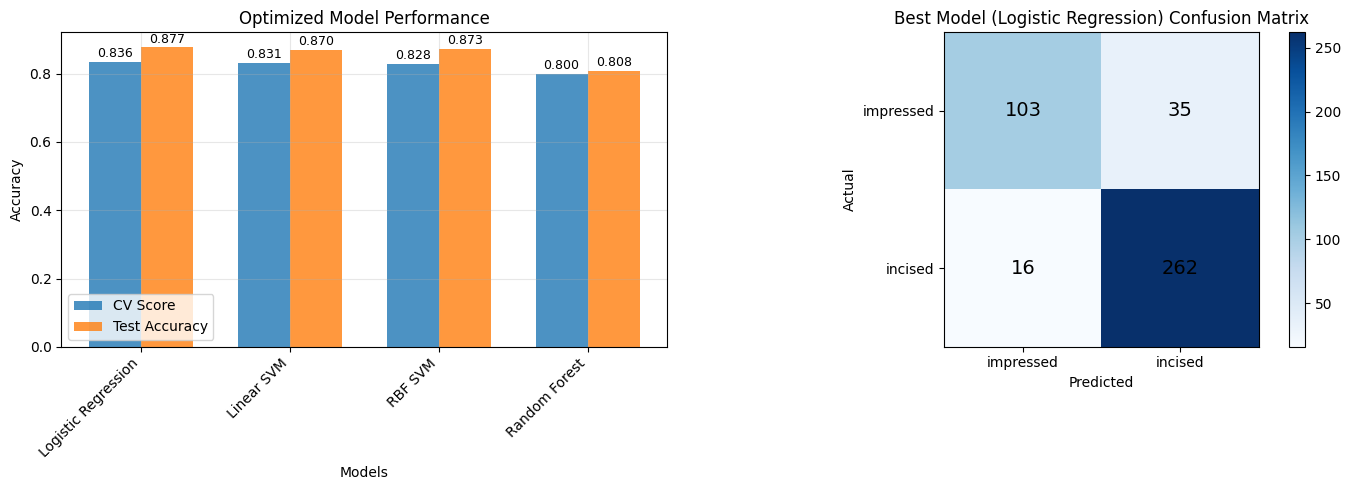

In [12]:
# 7c. Hyperparameter Optimization
# Find optimal parameters for each classifier

from sklearn.model_selection import GridSearchCV, cross_val_score

def optimize_hyperparameters(X_train, y_train, X_test, y_test):
    """Perform hyperparameter optimization for classifiers"""
    print("\n" + "=" * 70)
    print("HYPERPARAMETER OPTIMIZATION")
    print("=" * 70)
    
    optimized_results = {}
    
    # 1. Logistic Regression
    print("\n1. Optimizing Logistic Regression...")
    lr_params = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000]
    }
    
    lr_grid = GridSearchCV(
        LogisticRegression(random_state=42),
        lr_params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    start_time = time.time()
    lr_grid.fit(X_train, y_train)
    lr_time = time.time() - start_time
    
    lr_pred = lr_grid.best_estimator_.predict(X_test)
    lr_accuracy = accuracy_score(y_test, lr_pred)
    
    print(f"  Best parameters: {lr_grid.best_params_}")
    print(f"  Best CV score: {lr_grid.best_score_:.4f}")
    print(f"  Test accuracy: {lr_accuracy:.4f}")
    print(f"  Time: {lr_time:.2f}s")
    
    optimized_results['Logistic Regression'] = {
        'model': lr_grid.best_estimator_,
        'accuracy': lr_accuracy,
        'params': lr_grid.best_params_,
        'cv_score': lr_grid.best_score_
    }
    
    # 2. Linear SVM
    print("\n2. Optimizing Linear SVM...")
    svm_linear_params = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'kernel': ['linear']
    }
    
    svm_linear_grid = GridSearchCV(
        SVC(random_state=42),
        svm_linear_params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    start_time = time.time()
    svm_linear_grid.fit(X_train, y_train)
    svm_linear_time = time.time() - start_time
    
    svm_linear_pred = svm_linear_grid.best_estimator_.predict(X_test)
    svm_linear_accuracy = accuracy_score(y_test, svm_linear_pred)
    
    print(f"  Best parameters: {svm_linear_grid.best_params_}")
    print(f"  Best CV score: {svm_linear_grid.best_score_:.4f}")
    print(f"  Test accuracy: {svm_linear_accuracy:.4f}")
    print(f"  Time: {svm_linear_time:.2f}s")
    
    optimized_results['Linear SVM'] = {
        'model': svm_linear_grid.best_estimator_,
        'accuracy': svm_linear_accuracy,
        'params': svm_linear_grid.best_params_,
        'cv_score': svm_linear_grid.best_score_
    }
    
    # 3. RBF SVM
    print("\n3. Optimizing RBF SVM...")
    svm_rbf_params = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'kernel': ['rbf']
    }
    
    svm_rbf_grid = GridSearchCV(
        SVC(random_state=42),
        svm_rbf_params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    start_time = time.time()
    svm_rbf_grid.fit(X_train, y_train)
    svm_rbf_time = time.time() - start_time
    
    svm_rbf_pred = svm_rbf_grid.best_estimator_.predict(X_test)
    svm_rbf_accuracy = accuracy_score(y_test, svm_rbf_pred)
    
    print(f"  Best parameters: {svm_rbf_grid.best_params_}")
    print(f"  Best CV score: {svm_rbf_grid.best_score_:.4f}")
    print(f"  Test accuracy: {svm_rbf_accuracy:.4f}")
    print(f"  Time: {svm_rbf_time:.2f}s")
    
    optimized_results['RBF SVM'] = {
        'model': svm_rbf_grid.best_estimator_,
        'accuracy': svm_rbf_accuracy,
        'params': svm_rbf_grid.best_params_,
        'cv_score': svm_rbf_grid.best_score_
    }
    
    # 4. Random Forest
    print("\n4. Optimizing Random Forest...")
    rf_params = {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    
    rf_grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        rf_params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    start_time = time.time()
    rf_grid.fit(X_train, y_train)
    rf_time = time.time() - start_time
    
    rf_pred = rf_grid.best_estimator_.predict(X_test)
    rf_accuracy = accuracy_score(y_test, rf_pred)
    
    print(f"  Best parameters: {rf_grid.best_params_}")
    print(f"  Best CV score: {rf_grid.best_score_:.4f}")
    print(f"  Test accuracy: {rf_accuracy:.4f}")
    print(f"  Time: {rf_time:.2f}s")
    
    optimized_results['Random Forest'] = {
        'model': rf_grid.best_estimator_,
        'accuracy': rf_accuracy,
        'params': rf_grid.best_params_,
        'cv_score': rf_grid.best_score_
    }
    
    # Summary
    print("\n" + "=" * 70)
    print("OPTIMIZATION SUMMARY")
    print("=" * 70)
    print(f"{'Model':<20} {'Test Accuracy':<15} {'CV Score':<15}")
    print("-" * 70)
    
    for name, results in optimized_results.items():
        print(f"{name:<20} {results['accuracy']:<15.4f} {results['cv_score']:<15.4f}")
    
    # Find best model
    best_model_name = max(optimized_results.items(), key=lambda x: x[1]['accuracy'])[0]
    best_accuracy = optimized_results[best_model_name]['accuracy']
    
    print(f"\n✓ Best optimized model: {best_model_name} ({best_accuracy:.4f})")
    
    # Save optimized models
    print("\n" + "=" * 70)
    print("SAVING OPTIMIZED MODELS")
    print("=" * 70)
    
    models_dir = Path("models")
    models_dir.mkdir(parents=True, exist_ok=True)
    
    for name, results in optimized_results.items():
        model_filename = f"{selected_model_name}_{name.lower().replace(' ', '_')}_optimized.pkl"
        model_path = models_dir / model_filename
        
        try:
            # Save the optimized model
            joblib.dump(results['model'], model_path)
            print(f"✓ Saved: {model_path}")
            
            # Save hyperparameters
            params_filename = f"{selected_model_name}_{name.lower().replace(' ', '_')}_params.pkl"
            params_path = models_dir / params_filename
            joblib.dump(results['params'], params_path)
            print(f"✓ Saved params: {params_path}")
            
        except Exception as e:
            print(f"✗ Error saving {name}: {e}")
    
    print(f"\n✓ All optimized models saved to: {models_dir}")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    model_names = list(optimized_results.keys())
    test_accs = [r['accuracy'] for r in optimized_results.values()]
    cv_accs = [r['cv_score'] for r in optimized_results.values()]
    
    x_pos = np.arange(len(model_names))
    width = 0.35
    
    ax1.bar(x_pos - width/2, cv_accs, width, label='CV Score', alpha=0.8)
    ax1.bar(x_pos + width/2, test_accs, width, label='Test Accuracy', alpha=0.8)
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Optimized Model Performance')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(model_names, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for i, (cv, test) in enumerate(zip(cv_accs, test_accs)):
        ax1.text(i - width/2, cv + 0.005, f'{cv:.3f}', ha='center', va='bottom', fontsize=9)
        ax1.text(i + width/2, test + 0.005, f'{test:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Confusion matrix for best model
    best_model = optimized_results[best_model_name]['model']
    best_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, best_pred)
    
    im = ax2.imshow(cm, interpolation='nearest', cmap='Blues')
    ax2.set_title(f'Best Model ({best_model_name}) Confusion Matrix')
    plt.colorbar(im, ax=ax2)
    
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(label_encoder.classes_)
    ax2.set_yticklabels(label_encoder.classes_)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    
    for i in range(2):
        for j in range(2):
            ax2.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    return optimized_results

# Run hyperparameter optimization (this may take several minutes)
optimized_results = optimize_hyperparameters(X_train, y_train, X_test, y_test)

In [13]:
# 8. Evaluation & Model Saving
# Print detailed metrics and save model checkpoints

import os
from pathlib import Path

def evaluate_and_save_models(classifier_results, optimized_results, y_test, label_encoder, selected_model_name):
    """Evaluate models and save checkpoints"""
    
    # Create models directory
    models_dir = Path("models")
    models_dir.mkdir(parents=True, exist_ok=True)
    print(f"Created models directory: {models_dir}")
    
    print("\n" + "=" * 80)
    print("DETAILED EVALUATION RESULTS - BASIC MODELS")
    print("=" * 80)
    
    for name, results in classifier_results.items():
        clf = results['classifier']
        y_pred = results['predictions']
        accuracy = results['accuracy']
        train_time = results['train_time']
        
        print(f"\n{name.upper()}")
        print("-" * 50)
        print(f"Training time: {train_time:.2f}s")
        print(f"Accuracy: {accuracy:.4f}")
        
        # Detailed classification report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, 
                                  target_names=label_encoder.classes_))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        print("Confusion Matrix:")
        print(f"                 Predicted")
        print(f"                {label_encoder.classes_[0]:>8} {label_encoder.classes_[1]:>8}")
        print(f"Actual {label_encoder.classes_[0]:>8} {cm[0,0]:>8} {cm[0,1]:>8}")
        print(f"       {label_encoder.classes_[1]:>8} {cm[1,0]:>8} {cm[1,1]:>8}")
        
        # Save model checkpoint
        model_filename = f"{selected_model_name}_{name.lower().replace(' ', '_')}.pkl"
        model_path = models_dir / model_filename
        
        try:
            joblib.dump(clf, model_path)
            print(f"✓ Model saved: {model_path}")
        except Exception as e:
            print(f"✗ Error saving model: {e}")
    
    # Evaluate and display optimized models if available
    if optimized_results:
        print("\n" + "=" * 80)
        print("DETAILED EVALUATION RESULTS - OPTIMIZED MODELS")
        print("=" * 80)
        
        for name, results in optimized_results.items():
            clf = results['model']
            y_pred = clf.predict(X_test)
            accuracy = results['accuracy']
            
            print(f"\n{name.upper()} (OPTIMIZED)")
            print("-" * 50)
            print(f"Accuracy: {accuracy:.4f}")
            print(f"Best parameters: {results['params']}")
            print(f"Cross-validation score: {results['cv_score']:.4f}")
            
            # Detailed classification report
            print("\nClassification Report:")
            print(classification_report(y_test, y_pred, 
                                      target_names=label_encoder.classes_))
            
            # Confusion matrix
            cm = confusion_matrix(y_test, y_pred)
            print("Confusion Matrix:")
            print(f"                 Predicted")
            print(f"                {label_encoder.classes_[0]:>8} {label_encoder.classes_[1]:>8}")
            print(f"Actual {label_encoder.classes_[0]:>8} {cm[0,0]:>8} {cm[0,1]:>8}")
            print(f"       {label_encoder.classes_[1]:>8} {cm[1,0]:>8} {cm[1,1]:>8}")
    
    return models_dir

# Evaluate and save all models (basic and optimized)
models_dir = evaluate_and_save_models(classifier_results, optimized_results if 'optimized_results' in locals() else None, 
                                     y_test, label_encoder, selected_model_name)

print(f"\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Feature extractor: {selected_model_name}")
print(f"Total samples: {len(labels)}")
print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Feature dimension: {X_train.shape[1]}")
print(f"Models saved to: {models_dir}")

print(f"\nBasic Model Performance Ranking:")
sorted_results = sorted(classifier_results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for i, (name, results) in enumerate(sorted_results, 1):
    print(f"{i}. {name}: {results['accuracy']:.4f}")

if 'optimized_results' in locals() and optimized_results:
    print(f"\nOptimized Model Performance Ranking:")
    sorted_optimized = sorted(optimized_results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
    for i, (name, results) in enumerate(sorted_optimized, 1):
        print(f"{i}. {name}: {results['accuracy']:.4f}")
    
    # Compare best basic vs best optimized
    best_basic_acc = sorted_results[0][1]['accuracy']
    best_optimized_acc = sorted_optimized[0][1]['accuracy']
    improvement = (best_optimized_acc - best_basic_acc) * 100
    print(f"\n{'='*80}")
    print(f"Best basic model: {sorted_results[0][0]} ({best_basic_acc:.4f})")
    print(f"Best optimized model: {sorted_optimized[0][0]} ({best_optimized_acc:.4f})")
    print(f"Improvement: {improvement:+.2f} percentage points")

print(f"\n✓ All models trained, evaluated, and saved successfully!")

Created models directory: models

DETAILED EVALUATION RESULTS - BASIC MODELS

LOGISTIC REGRESSION
--------------------------------------------------
Training time: 0.19s
Accuracy: 0.8365

Classification Report:
              precision    recall  f1-score   support

   impressed       0.77      0.72      0.75       138
     incised       0.87      0.89      0.88       278

    accuracy                           0.84       416
   macro avg       0.82      0.81      0.81       416
weighted avg       0.83      0.84      0.84       416

Confusion Matrix:
                 Predicted
                impressed  incised
Actual impressed      100       38
        incised       30      248
✓ Model saved: models\dinov2_vitl14_logistic_regression.pkl

LINEAR SVM
--------------------------------------------------
Training time: 0.24s
Accuracy: 0.8221

Classification Report:
              precision    recall  f1-score   support

   impressed       0.73      0.73      0.73       138
     incised       

In [14]:
# 9. Model Loading Example
# Demonstrate how to load and use saved models for inference

def load_and_predict_example():
    """Example of loading a saved model and making predictions"""
    
    print("MODEL LOADING EXAMPLE")
    print("=" * 50)
    
    # List all saved models
    models_dir = Path("models")
    if models_dir.exists():
        saved_models = list(models_dir.glob("*.pkl"))
        # Separate models and params
        model_files = [m for m in saved_models if not m.name.endswith('_params.pkl')]
        param_files = [m for m in saved_models if m.name.endswith('_params.pkl')]
        
        print(f"Found {len(model_files)} saved model(s):")
        for model_path in sorted(model_files):
            print(f"  - {model_path.name}")
        
        if param_files:
            print(f"\nFound {len(param_files)} parameter file(s):")
            for param_path in sorted(param_files):
                print(f"  - {param_path.name}")
    else:
        print("No models directory found")
        return
    
    if model_files:
        # Find best optimized model
        optimized_models = [m for m in model_files if 'optimized' in m.name]
        
        if optimized_models:
            # Load best optimized model
            print(f"\n{'='*50}")
            print("LOADING BEST OPTIMIZED MODEL")
            print("="*50)
            
            # Get accuracies to find best
            if 'optimized_results' in locals() and optimized_results:
                best_opt_name = max(optimized_results.items(), key=lambda x: x[1]['accuracy'])[0]
                best_opt_file = f"{selected_model_name}_{best_opt_name.lower().replace(' ', '_')}_optimized.pkl"
                best_opt_path = models_dir / best_opt_file
                param_file = f"{selected_model_name}_{best_opt_name.lower().replace(' ', '_')}_params.pkl"
                param_path = models_dir / param_file
            else:
                best_opt_path = optimized_models[0]
                param_path = None
            
            if best_opt_path.exists():
                print(f"Loading: {best_opt_path.name}")
                
                try:
                    # Load the classifier
                    loaded_classifier = joblib.load(best_opt_path)
                    print("✓ Model loaded successfully")
                    
                    # Load parameters if available
                    if param_path and param_path.exists():
                        loaded_params = joblib.load(param_path)
                        print(f"✓ Parameters loaded: {loaded_params}")
                    
                    # Make predictions on test set
                    y_pred_loaded = loaded_classifier.predict(X_test)
                    accuracy_loaded = accuracy_score(y_test, y_pred_loaded)
                    
                    print(f"\nModel performance:")
                    print(f"  Accuracy: {accuracy_loaded:.4f}")
                    
                    # Show sample predictions
                    print(f"\nSample predictions (first 10):")
                    print(f"{'Actual':<12} {'Predicted':<12} {'Correct':<10}")
                    print("-" * 40)
                    for i in range(min(10, len(y_test))):
                        actual_label = label_encoder.inverse_transform([y_test[i]])[0]
                        pred_label = label_encoder.inverse_transform([y_pred_loaded[i]])[0]
                        correct = "✓" if y_test[i] == y_pred_loaded[i] else "✗"
                        print(f"{actual_label:<12} {pred_label:<12} {correct:<10}")
                    
                    print("\n✓ Model loading and prediction successful!")
                    
                except Exception as e:
                    print(f"✗ Error loading model: {e}")
        else:
            # Load best basic model
            print(f"\n{'='*50}")
            print("LOADING BEST BASIC MODEL")
            print("="*50)
            
            if 'sorted_results' in locals():
                best_model_name = sorted_results[0][0]
                best_model_file = f"{selected_model_name}_{best_model_name.lower().replace(' ', '_')}.pkl"
                best_model_path = models_dir / best_model_file
            else:
                best_model_path = model_files[0]
            
            if best_model_path.exists():
                print(f"Loading: {best_model_path.name}")
                
                try:
                    loaded_classifier = joblib.load(best_model_path)
                    print("✓ Model loaded successfully")
                    
                    y_pred_loaded = loaded_classifier.predict(X_test)
                    accuracy_loaded = accuracy_score(y_test, y_pred_loaded)
                    
                    print(f"Loaded model accuracy: {accuracy_loaded:.4f}")
                    print("✓ Model loading and prediction successful!")
                    
                except Exception as e:
                    print(f"✗ Error loading model: {e}")
    else:
        print("No saved models found")

# Run the example
load_and_predict_example()

MODEL LOADING EXAMPLE
Found 9 saved model(s):
  - dinov2_vitl14_linear_svm.pkl
  - dinov2_vitl14_linear_svm_optimized.pkl
  - dinov2_vitl14_logistic_regression.pkl
  - dinov2_vitl14_logistic_regression_optimized.pkl
  - dinov2_vitl14_random_forest.pkl
  - dinov2_vitl14_random_forest_optimized.pkl
  - dinov2_vitl14_rbf_svm.pkl
  - dinov2_vitl14_rbf_svm_optimized.pkl
  - dinov2_vitl14_xgboost.pkl

Found 4 parameter file(s):
  - dinov2_vitl14_linear_svm_params.pkl
  - dinov2_vitl14_logistic_regression_params.pkl
  - dinov2_vitl14_random_forest_params.pkl
  - dinov2_vitl14_rbf_svm_params.pkl

LOADING BEST OPTIMIZED MODEL
Loading: dinov2_vitl14_linear_svm_optimized.pkl
✓ Model loaded successfully

Model performance:
  Accuracy: 0.8702

Sample predictions (first 10):
Actual       Predicted    Correct   
----------------------------------------
impressed    incised      ✗         
incised      impressed    ✗         
incised      incised      ✓         
impressed    impressed    ✓         
im